# Reproduce Results — Breast Cancer Classification on CBIS-DDSM
### 24-788 Introduction to Deep Learning, Spring 2026
**Team:** Aadya Goel (aadyag) · Amisha Dhawan (adhawan)

This notebook is fully self-contained. It:
1. Installs dependencies
2. Mounts Google Drive to load saved model checkpoints
3. Downloads the CBIS-DDSM dataset from Kaggle
4. Rebuilds the test set and evaluates all three models
5. Regenerates all figures and metrics from the report

**No retraining required.**


## Step 1 — Install Dependencies

In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy kaggle -q
print("Done.")

Done.


## Step 2 — Upload files (Model Checkpoints)

In [4]:
!pip install gdown -q

import gdown, os

CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

checkpoints = {
    "ResNet50_Transfer_ft_best.keras":      "18ZNgjpt3vAz1rnoSIHP9jxahsyyi3dFG",
    "ANN_Baseline_final.keras":              "1ChETyrR7DJTIGC4tQ9yIIH16t-GfTHaK",
    "EfficientNetB0_Transfer_ft_best.keras":"1HTDS0g1YKnid95JZAMEXgzRvcBOFVw9n",
}

for fname, file_id in checkpoints.items():
    output = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(output):
        print(f"Downloading {fname}...")
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)
    else:
        print(f"Already exists: {fname}")

print("\nChecking checkpoints:")
for fname in checkpoints:
    path = os.path.join(CKPT_DIR, fname)
    print(f"  {'' if os.path.exists(path) else 'MISSING'}: {fname}")

Already exists: ResNet50_Transfer_ft_best.keras


Downloading...
From (original): https://drive.google.com/uc?id=1ChETyrR7DJTIGC4tQ9yIIH16t-GfTHaK
From (redirected): https://drive.google.com/uc?id=1ChETyrR7DJTIGC4tQ9yIIH16t-GfTHaK&confirm=t&uuid=517d4ae0-16c6-4560-a50a-d69635789280
To: /content/checkpoints/ANN_Baseline_final.keras
100%|██████████| 927M/927M [00:13<00:00, 68.0MB/s]

Already exists: EfficientNetB0_Transfer_ft_best.keras

Checking checkpoints:
  : ResNet50_Transfer_ft_best.keras
  : ANN_Baseline_final.keras
  : EfficientNetB0_Transfer_ft_best.keras


## Step 3 — Download CBIS-DDSM Dataset

In [5]:
from google.colab import files as colab_files
# print("Upload kaggle.json:")
# colab_files.upload()

# os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
# os.system("cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")

DATA_ROOT = "/content/cbis-ddsm"
if not os.path.exists(DATA_ROOT):
    print("Downloading dataset (~3.5 GB)...")
    os.system(f"kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset --unzip -p {DATA_ROOT}")
    print("Download complete.")
else:
    print("Dataset already present.")

csv_dir = os.path.join(DATA_ROOT, "csv")
img_dir = os.path.join(DATA_ROOT, "jpeg")

Download complete.


## Step 4 — Imports & Config

In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
warnings.filterwarnings("ignore")

SEED       = 42
IMG_SIZE   = 224
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: []


## Step 5 — Build Test Dataset

In [7]:
def load_split(split):
    calc = pd.read_csv(f"{csv_dir}/calc_case_description_{split}_set.csv")
    mass = pd.read_csv(f"{csv_dir}/mass_case_description_{split}_set.csv")
    return pd.concat([calc, mass], ignore_index=True)

dicom_info = pd.read_csv(f"{csv_dir}/dicom_info.csv")
full_mammo = dicom_info[dicom_info["SeriesDescription"] == "full mammogram images"].copy()

def strip_suffix(pid):
    parts = str(pid).split("_")
    return "_".join(parts[:-1]) if parts[-1].isdigit() else pid

full_mammo["key"] = full_mammo["PatientID"].apply(strip_suffix)

def build_image_lookup(img_dir, full_mammo):
    lookup = {}
    for _, row in full_mammo.iterrows():
        key = row["key"]
        if key in lookup:
            continue
        uid = str(row["image_path"]).replace("CBIS-DDSM/jpeg/", "").split("/")[0]
        folder_path = os.path.join(img_dir, uid)
        if not os.path.isdir(folder_path):
            continue
        jpgs = [f for f in os.listdir(folder_path)
                if f.lower().endswith(".jpg") or f.lower().endswith(".jpeg")]
        if jpgs:
            lookup[key] = os.path.join(folder_path, sorted(jpgs)[0])
    return lookup

print("Building image lookup...")
img_lookup = build_image_lookup(img_dir, full_mammo)
print(f"Found {len(img_lookup)} images.")

def prepare_df(df_raw):
    df = df_raw.copy()
    df["pathology"] = df["pathology"].str.strip().replace("BENIGN_WITHOUT_CALLBACK", "BENIGN")
    df = df[df["pathology"].isin(["BENIGN", "MALIGNANT"])].copy()
    def strip_folder(s):
        parts = str(s).split("/")[0].split("_")
        return "_".join(parts[:-1]) if parts[-1].isdigit() else str(s).split("/")[0]
    df["folder"]   = df["image file path"].apply(strip_folder)
    df["img_path"] = df["folder"].map(img_lookup)
    df = df.dropna(subset=["img_path"]).reset_index(drop=True)
    df["label"] = (df["pathology"] == "MALIGNANT").astype(int)
    return df[["img_path", "label", "pathology"]]

df_test = prepare_df(load_split("test"))
print(f"Test set: {len(df_test)} samples")
print(df_test["pathology"].value_counts())

def preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df):
    ds = tf.data.Dataset.from_tensor_slices(
        (df["img_path"].values, df["label"].values.astype("float32"))
    )
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

test_ds = make_dataset(df_test)
print("Test dataset ready.")

Building image lookup...
Found 2857 images.
Test set: 422 samples
pathology
BENIGN       248
MALIGNANT    174
Name: count, dtype: int64
Test dataset ready.


## Step 6 — Load Checkpoints & Evaluate

In [8]:
def evaluate_model(model, test_ds, display_name):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0).flatten()
        y_pred_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().tolist())
    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    report = classification_report(y_true, y_pred,
                                   target_names=["Benign", "Malignant"],
                                   output_dict=True)
    auc = roc_auc_score(y_true, y_pred_prob)
    print(f"\n{'='*55}\n  {display_name}\n{'='*55}")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
    print(f"  AUC-ROC: {auc:.4f}")
    return {
        "model":       display_name,
        "accuracy":    report["accuracy"],
        "auc":         auc,
        "precision":   report["Malignant"]["precision"],
        "recall":      report["Malignant"]["recall"],
        "f1":          report["Malignant"]["f1-score"],
        "y_true":      y_true,
        "y_pred_prob": y_pred_prob,
    }

model_files   = ["ANN_Baseline_final.keras",
                 "ResNet50_Transfer_ft_best.keras",
                 "EfficientNetB0_Transfer_ft_best.keras"]
display_names = ["ANN Baseline", "ResNet50", "EfficientNetB0"]
all_metrics   = []

for fname, display_name in zip(model_files, display_names):
    path = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(path):
        print(f"WARNING: {fname} not found — skipping.")
        continue
    print(f"Loading {path} ...")
    model = keras.models.load_model(path)
    metrics = evaluate_model(model, test_ds, display_name)
    all_metrics.append(metrics)

print(f"\n✓ Evaluated {len(all_metrics)} models.")

Loading /content/checkpoints/ANN_Baseline_final.keras ...

  ANN Baseline
              precision    recall  f1-score   support

      Benign       0.65      0.62      0.63       248
   Malignant       0.49      0.52      0.50       174

    accuracy                           0.58       422
   macro avg       0.57      0.57      0.57       422
weighted avg       0.58      0.58      0.58       422

  AUC-ROC: 0.6343
Loading /content/checkpoints/ResNet50_Transfer_ft_best.keras ...

  ResNet50
              precision    recall  f1-score   support

      Benign       0.68      0.76      0.72       248
   Malignant       0.58      0.48      0.53       174

    accuracy                           0.64       422
   macro avg       0.63      0.62      0.62       422
weighted avg       0.64      0.64      0.64       422

  AUC-ROC: 0.7014
Loading /content/checkpoints/EfficientNetB0_Transfer_ft_best.keras ...

  EfficientNetB0
              precision    recall  f1-score   support

      Benign   

## Step 7 — Regenerate Figures

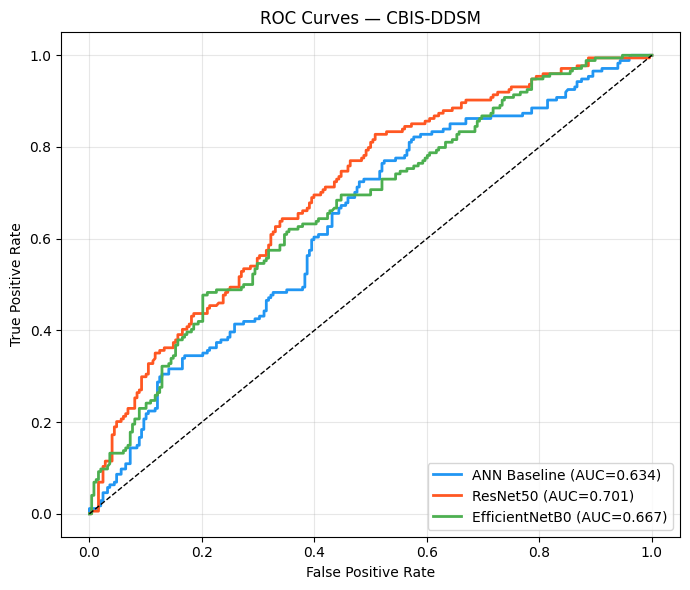

Saved: roc_curves_repro.png


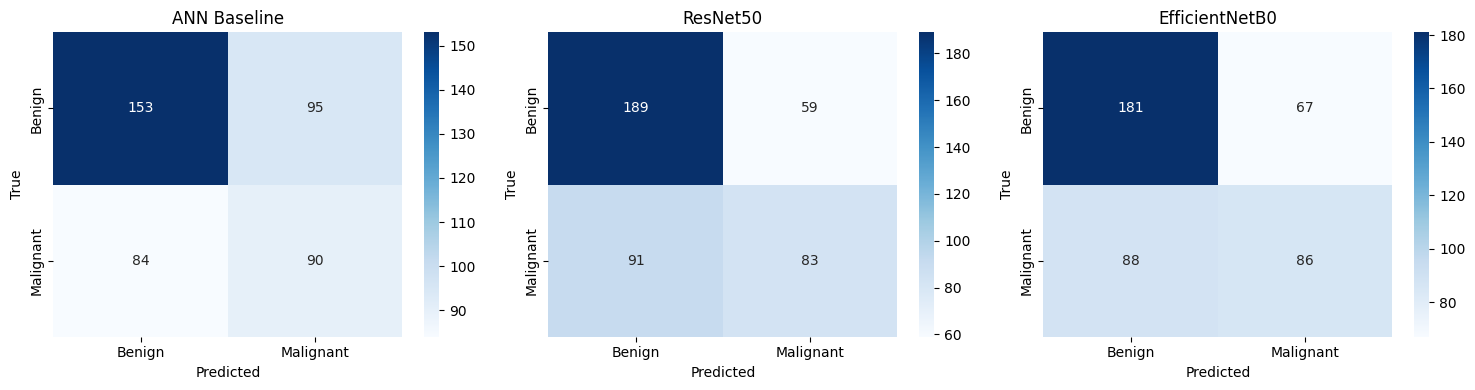

Saved: confusion_matrices_repro.png


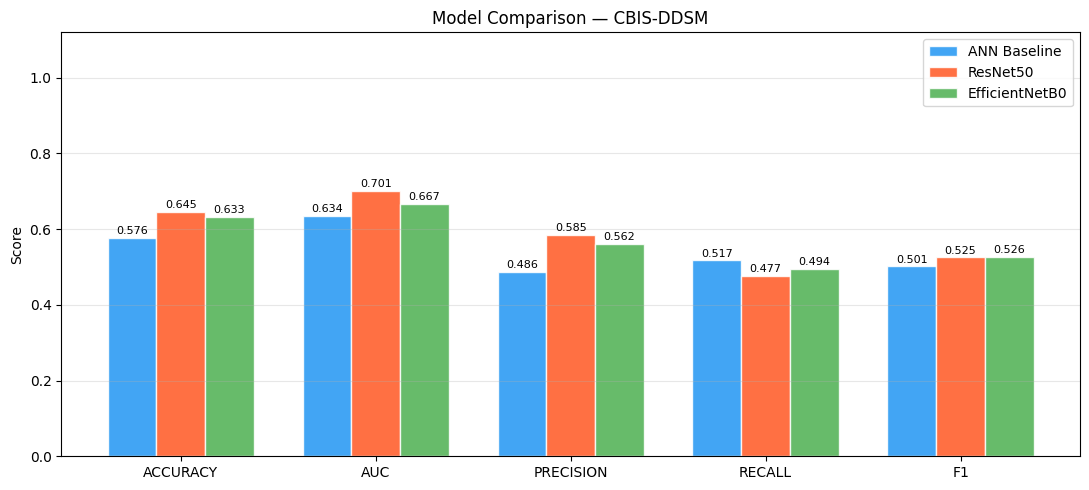

Saved: model_comparison_repro.png

✓ All figures reproduced successfully.


In [9]:
colors = ["#2196F3", "#FF5722", "#4CAF50"]

# ROC Curves
plt.figure(figsize=(7, 6))
for m, color in zip(all_metrics, colors):
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred_prob"])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{m['model']} (AUC={m['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — CBIS-DDSM"); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves_repro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves_repro.png")

# Confusion Matrices
fig, axes = plt.subplots(1, len(all_metrics), figsize=(5 * len(all_metrics), 4))
if len(all_metrics) == 1: axes = [axes]
for ax, m in zip(axes, all_metrics):
    y_pred = (m["y_pred_prob"] >= 0.5).astype(int)
    cm = confusion_matrix(m["y_true"], y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(m["model"]); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrices_repro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_repro.png")

# Metric Comparison Bar Chart
metric_keys = ["accuracy", "auc", "precision", "recall", "f1"]
x = np.arange(len(metric_keys)); width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, color) in enumerate(zip(all_metrics, colors)):
    vals = [m[k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=m["model"],
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels([k.upper() for k in metric_keys])
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Model Comparison — CBIS-DDSM"); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison_repro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison_repro.png")

print("\n✓ All figures reproduced successfully.")